In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jb

In [4]:
import sys

!{sys.executable} -m pip install openpyxl

You should consider upgrading via the 'c:\Users\srikh\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [5]:
BASE_DIR = os.path.dirname(os.getcwd())
print(BASE_DIR)

dataset_path = os.path.join(
    BASE_DIR,
    "aqua farm ml datasets",
    "WQD.xlsx"
)
print(dataset_path)

dataset = pd.read_excel(dataset_path)

d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System
d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System\aqua farm ml datasets\WQD.xlsx


In [6]:
dataset

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,29.735524,38.317998,3.018023,1.693656,6.812760,7.520074,60.569195,87.187465,54.917947,0.016649,0.017729,0.049214,0.019651,4324.636990,0
4296,23.790212,51.921647,3.577539,1.603779,6.320979,8.920212,37.596390,110.850912,93.497161,0.007924,0.003012,0.171120,0.019129,3234.144448,0
4297,26.968422,44.845416,4.309935,1.390583,7.219665,8.244524,41.018992,147.464264,55.920616,0.008396,0.019906,0.726881,0.019108,3816.443939,0
4298,24.523092,57.128596,4.743615,1.471877,5.762763,8.387189,58.393898,144.565612,56.450780,0.012405,0.004498,0.827799,0.019905,3580.989358,0


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temp                  4300 non-null   float64
 1   Turbidity (cm)        4300 non-null   float64
 2   DO(mg/L)              4300 non-null   float64
 3   BOD (mg/L)            4300 non-null   float64
 4   CO2                   4300 non-null   float64
 5   pH`                   4300 non-null   float64
 6   Alkalinity (mg L-1 )  4300 non-null   float64
 7   Hardness (mg L-1 )    4300 non-null   float64
 8   Calcium (mg L-1 )     4300 non-null   float64
 9   Ammonia (mg L-1 )     4300 non-null   float64
 10  Nitrite (mg L-1 )     4300 non-null   float64
 11  Phosphorus (mg L-1 )  4300 non-null   float64
 12  H2S (mg L-1 )         4300 non-null   float64
 13  Plankton (No. L-1)    4300 non-null   float64
 14  Water Quality         4300 non-null   int64  
dtypes: float64(14), int64

In [8]:
print(pd.isnull(dataset).sum())

Temp                    0
Turbidity (cm)          0
DO(mg/L)                0
BOD (mg/L)              0
CO2                     0
pH`                     0
Alkalinity (mg L-1 )    0
Hardness (mg L-1 )      0
Calcium (mg L-1 )       0
Ammonia (mg L-1 )       0
Nitrite (mg L-1 )       0
Phosphorus (mg L-1 )    0
H2S (mg L-1 )           0
Plankton (No. L-1)      0
Water Quality           0
dtype: int64


In [9]:
dataset.describe()

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,25.695663,39.046681,5.300346,3.125079,6.375929,7.713468,93.717183,127.055476,84.871932,0.048269,0.642948,1.172749,0.016473,3805.510620,1.023256
std,9.670202,20.942726,1.832736,2.292060,2.831104,1.580282,68.949048,78.883091,75.718842,0.122886,0.903592,1.082648,0.011874,1208.547783,0.820996
min,0.194046,0.051424,0.133928,1.000621,0.001155,0.003944,25.012328,0.255805,0.018293,0.000001,0.000025,0.000128,0.000002,78.603733,0.000000
25%,19.775926,22.224140,3.978366,1.522077,5.048761,6.443019,40.422364,69.479620,23.745078,0.012750,0.010636,0.028355,0.010072,2956.020049,0.000000
50%,25.041849,30.205696,5.000754,2.236022,6.598076,7.743176,67.562607,111.063301,62.845419,0.026335,0.099908,0.975312,0.019049,3729.396476,1.000000
75%,30.277718,55.945735,6.521225,4.324578,8.241532,9.035251,132.834386,162.675648,115.596833,0.039016,1.166714,2.101317,0.019567,4555.089727,2.000000
max,84.251522,99.797743,14.970122,14.943006,14.984216,14.851195,299.913160,398.796550,399.321398,0.999300,4.989535,4.974457,0.099220,7460.415789,2.000000


In [10]:
duplicates = dataset.duplicated().sum()
print(f'The number of duplicates is {duplicates}')

The number of duplicates is 0


In [11]:
dataset_shape = dataset.shape
print(f'The dataset shape is {dataset_shape}')

The dataset shape is (4300, 15)


In [12]:
dataset_object_type = dataset.dtypes
print(dataset_object_type)

Temp                    float64
Turbidity (cm)          float64
DO(mg/L)                float64
BOD (mg/L)              float64
CO2                     float64
pH`                     float64
Alkalinity (mg L-1 )    float64
Hardness (mg L-1 )      float64
Calcium (mg L-1 )       float64
Ammonia (mg L-1 )       float64
Nitrite (mg L-1 )       float64
Phosphorus (mg L-1 )    float64
H2S (mg L-1 )           float64
Plankton (No. L-1)      float64
Water Quality             int64
dtype: object


In [13]:
numeric_columns =  dataset.select_dtypes(include='number').columns
print(numeric_columns)

Index(['Temp', 'Turbidity (cm)', 'DO(mg/L)', 'BOD (mg/L)', 'CO2', 'pH`',
       'Alkalinity (mg L-1 )', 'Hardness (mg L-1 )', 'Calcium (mg L-1 )',
       'Ammonia (mg L-1 )', 'Nitrite (mg L-1 )', 'Phosphorus (mg L-1 )',
       'H2S (mg L-1 )', 'Plankton (No. L-1)', 'Water Quality'],
      dtype='object')


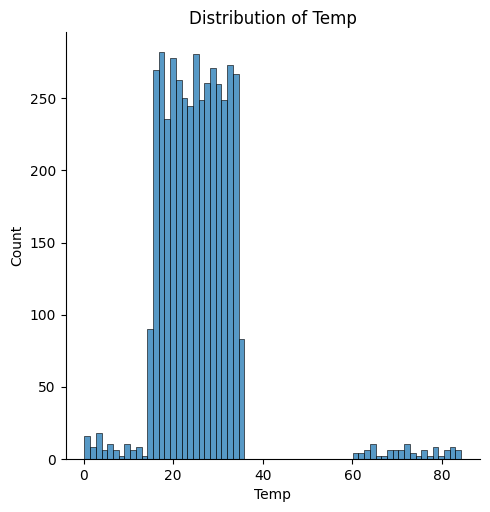

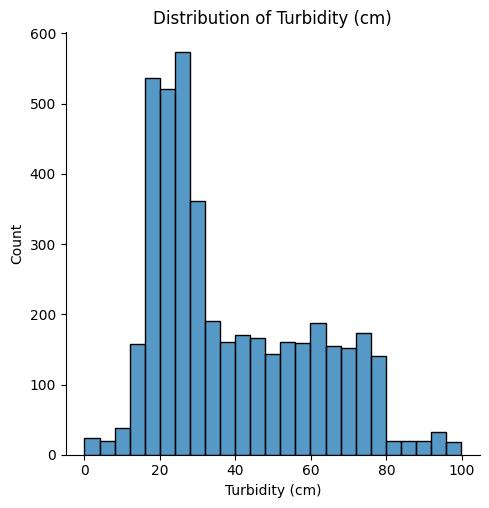

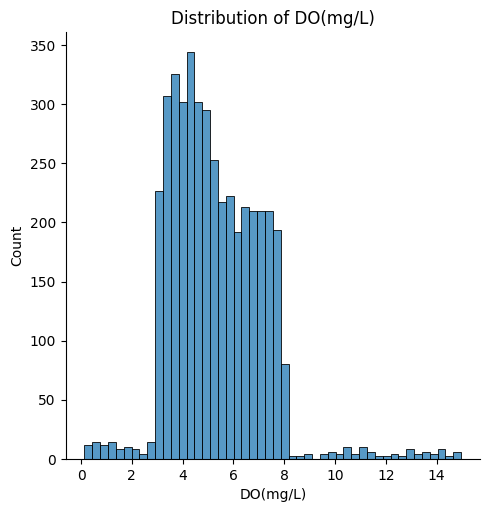

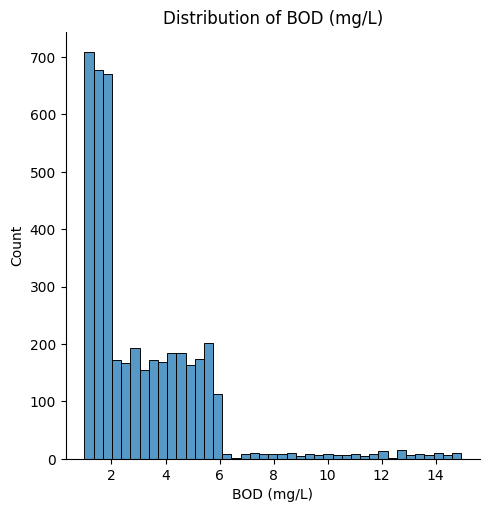

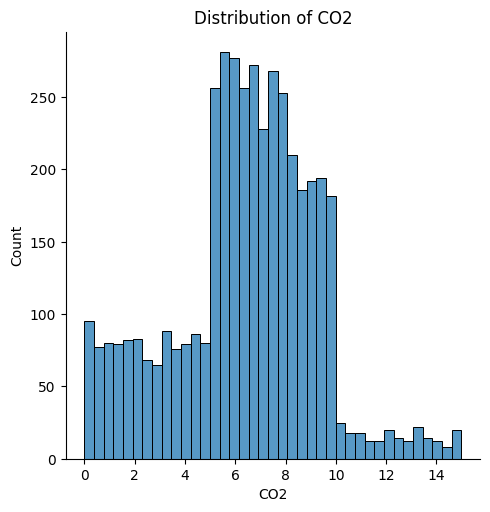

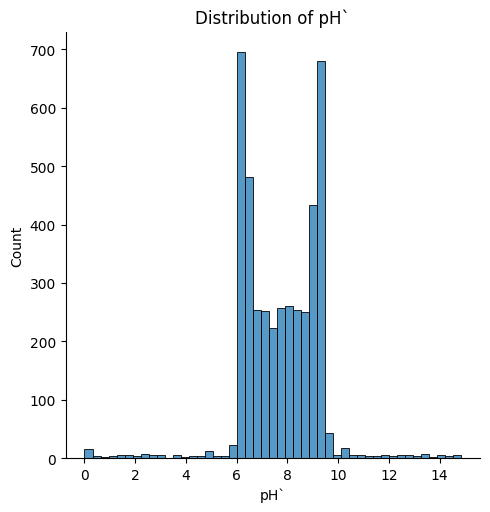

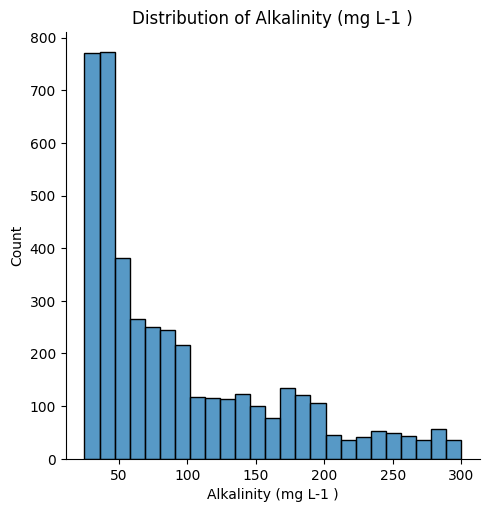

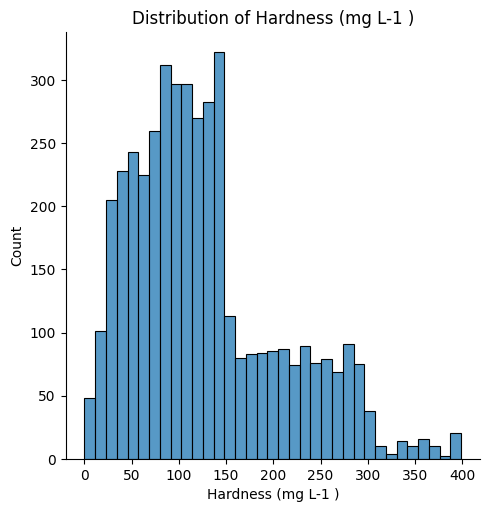

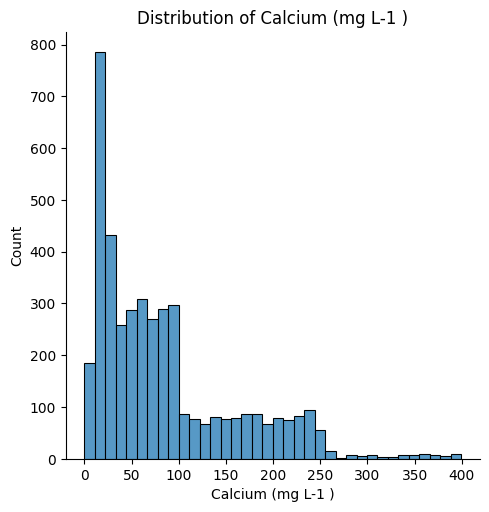

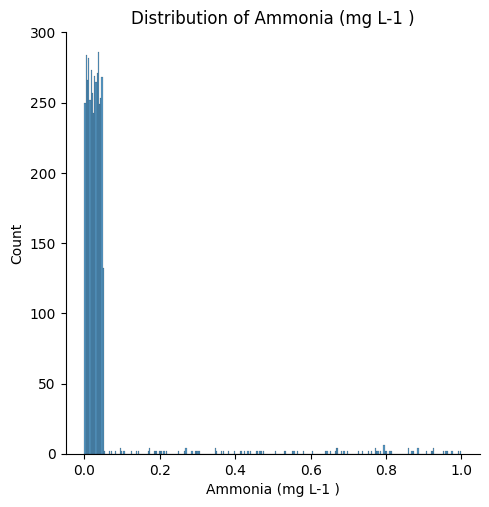

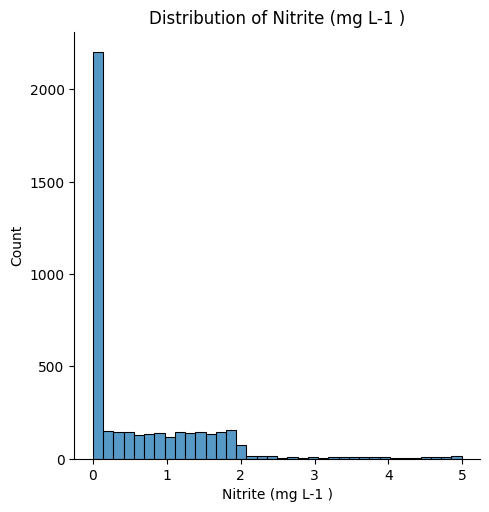

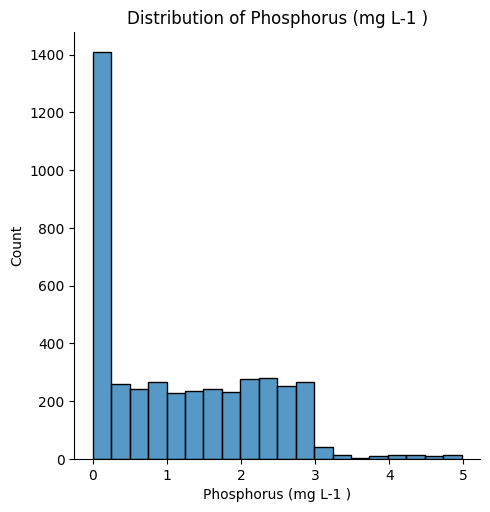

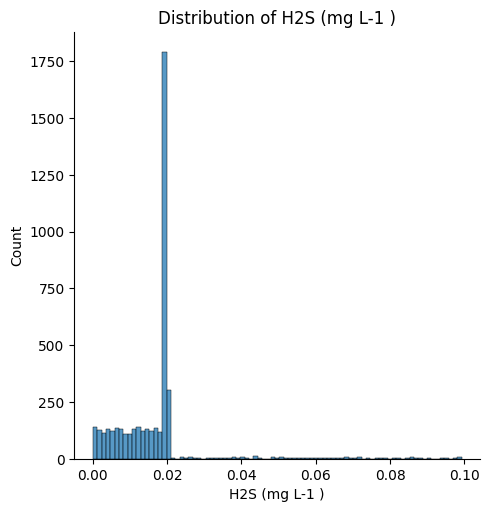

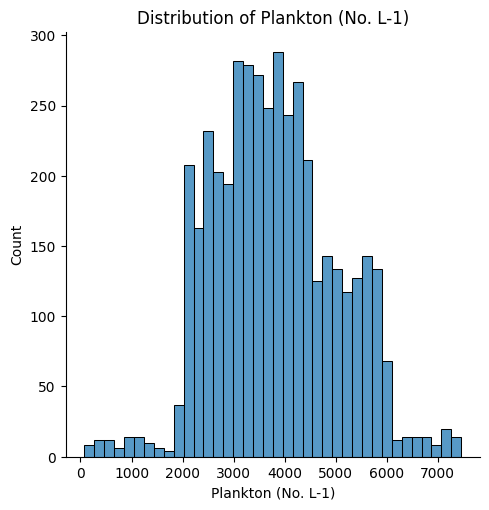

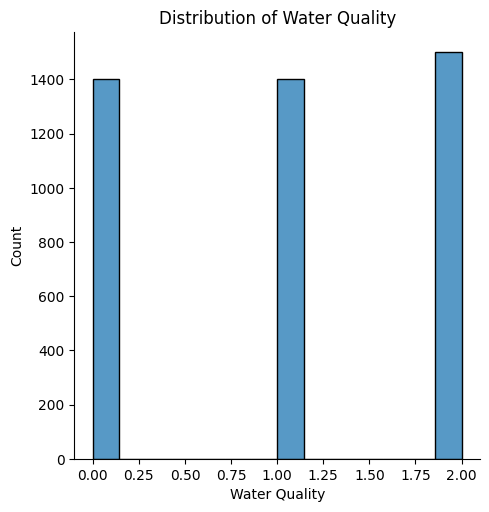

In [14]:
for col in numeric_columns:
    plt.Figure(figsize=(10,10))
    sns.displot(dataset[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [15]:
categorical_columns = dataset.select_dtypes(include='object').columns
print(categorical_columns)

Index([], dtype='object')


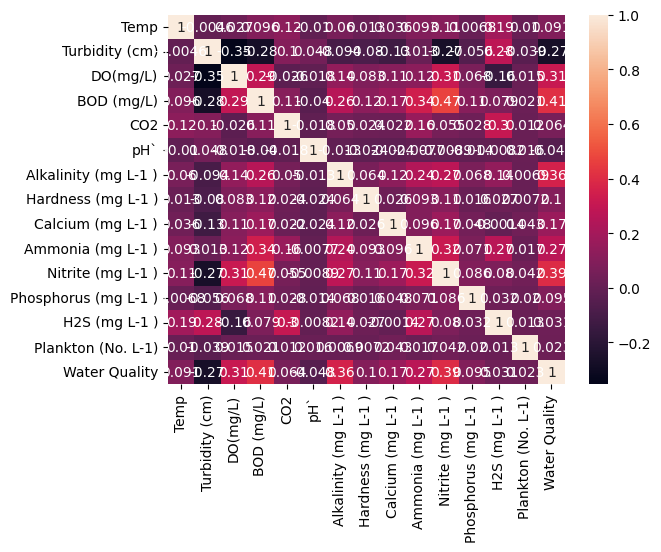

In [16]:
sns.heatmap(dataset[numeric_columns].corr(), annot=True)
plt.show()

In [17]:
x = dataset.drop('Water Quality', axis=1)

In [18]:
x

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1)
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,29.735524,38.317998,3.018023,1.693656,6.812760,7.520074,60.569195,87.187465,54.917947,0.016649,0.017729,0.049214,0.019651,4324.636990
4296,23.790212,51.921647,3.577539,1.603779,6.320979,8.920212,37.596390,110.850912,93.497161,0.007924,0.003012,0.171120,0.019129,3234.144448
4297,26.968422,44.845416,4.309935,1.390583,7.219665,8.244524,41.018992,147.464264,55.920616,0.008396,0.019906,0.726881,0.019108,3816.443939
4298,24.523092,57.128596,4.743615,1.471877,5.762763,8.387189,58.393898,144.565612,56.450780,0.012405,0.004498,0.827799,0.019905,3580.989358


In [19]:
y = dataset['Water Quality']

In [20]:
y

0       2
1       2
2       2
3       2
4       2
       ..
4295    0
4296    0
4297    0
4298    0
4299    0
Name: Water Quality, Length: 4300, dtype: int64

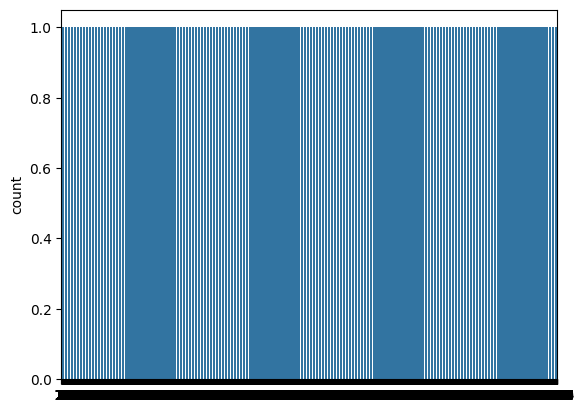

In [21]:
sns.countplot(y)
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
x_train

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1)
2605,32.464786,27.293330,5.861614,5.750653,4.117721,9.312726,27.237966,60.455821,108.289603,0.038709,1.935747,2.541506,0.014644,5131.997064
3328,28.615592,69.353055,4.773766,1.391248,6.191995,8.739606,48.788574,77.158953,88.482695,0.006780,0.011814,0.557068,0.019203,3450.214259
3404,20.047741,74.773093,3.694377,1.334189,5.496537,8.090101,71.488048,148.104513,32.436297,0.020546,0.006297,1.816223,0.019197,4090.206161
1588,32.081656,24.795449,7.601435,3.594280,9.117331,6.065921,38.945830,21.889869,14.025017,0.037487,0.322882,2.403058,0.002654,2541.580375
1612,34.534884,18.364022,6.954687,2.576635,3.860890,9.161987,34.183293,285.441647,226.078670,0.026511,0.956482,2.063847,0.015003,2799.548682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3444,29.275445,34.309015,3.801261,1.291671,5.900797,8.586685,62.937977,112.204437,27.367791,0.021162,0.014107,1.833152,0.019776,3026.678773
466,20.637565,71.980930,3.606747,14.245353,5.222039,7.857114,84.962281,144.852192,45.894305,0.024486,0.006857,1.542330,0.019753,3056.770086
3092,20.083919,43.713128,4.576816,1.299694,7.002338,7.830125,51.515579,79.736444,32.001898,0.014756,0.004728,0.623748,0.019933,3882.772215
3772,23.939123,60.296681,4.552364,1.683085,6.149709,8.613454,33.010747,142.391463,58.855092,0.007353,0.002425,0.279545,0.019542,3102.110528


In [24]:
x_test

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1)
1760,30.338537,15.168593,7.032630,2.479024,4.327260,9.190922,45.626967,204.197177,161.849721,0.030665,1.705603,0.028574,0.014698,2186.056662
3035,26.865941,49.634091,4.391976,1.860846,6.688350,6.751112,85.650522,145.920152,80.228303,0.002497,0.000431,0.682563,0.019837,3094.418437
1921,15.477427,26.703443,5.764126,3.725595,1.215205,6.079626,115.442729,271.245686,15.793144,0.027019,0.339209,2.558911,0.014785,4608.000889
1188,28.305607,19.756460,4.089812,4.424872,3.094032,6.710983,29.750587,270.408077,78.302718,0.020521,4.924597,1.026471,0.007937,2294.082475
109,1.098151,19.216598,6.465732,4.628758,9.999986,6.174835,168.734661,245.265025,184.129290,0.031447,1.201478,2.689077,0.012980,5160.868893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3559,22.391514,63.789627,4.172929,1.732036,7.427659,8.639719,29.044117,101.945748,41.564485,0.017103,0.015170,0.199010,0.019933,3483.111027
1455,34.064720,65.545745,4.943572,1.543270,9.782816,6.162275,26.273445,44.791112,59.972299,0.037647,0.019041,0.331863,0.015291,78.603733
2812,15.873862,29.483245,5.814690,3.544321,2.915877,6.125467,159.167004,232.680587,148.701292,0.043144,0.884339,2.828323,0.011652,5302.784610
3459,23.040106,66.237537,4.851934,1.851519,5.657814,6.780730,70.935338,147.728000,63.950887,0.018556,0.014137,1.655325,0.019225,3006.293729


In [25]:
y_train

2605    1
3328    0
3404    0
1588    1
1612    1
       ..
3444    0
466     2
3092    0
3772    0
860     2
Name: Water Quality, Length: 3440, dtype: int64

In [26]:
y_test

1760    1
3035    0
1921    1
1188    2
109     2
       ..
3559    0
1455    2
2812    1
3459    0
1393    2
Name: Water Quality, Length: 860, dtype: int64

In [27]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [28]:
x_train

array([[ 0.69692309, -0.56665658,  0.30151888, ...,  1.27473264,
        -0.1507425 ,  1.10122943],
       [ 0.29835413,  1.44322755, -0.290754  , ..., -0.56893939,
         0.2380824 , -0.29718149],
       [-0.58881335,  1.70223182, -0.87842093, ...,  0.60089791,
         0.23758986,  0.23497502],
       ...,
       [-0.58506725,  0.21798696, -0.39798183, ..., -0.50698866,
         0.30034566,  0.06249264],
       [-0.185876  ,  1.01045579, -0.41129491, ..., -0.82677553,
         0.26704318, -0.58663151],
       [ 0.25274916,  1.35089834, -1.16165275, ...,  1.05707483,
        -0.3891021 ,  0.58052961]], shape=(3440, 14))

In [29]:
x_test

array([[ 0.47675831, -1.14605446,  0.93907138, ..., -1.05994452,
        -0.14615905, -1.34833494],
       [ 0.11718457,  0.50092867, -0.49861681, ..., -0.45234557,
         0.29215532, -0.59302752],
       [-1.0620515 , -0.59484517,  0.24844181, ...,  1.29090349,
        -0.13878057,  0.66552396],
       ...,
       [-1.02100222, -0.46200836,  0.27597128, ...,  1.54120461,
        -0.40595901,  1.24324014],
       [-0.2789657 ,  1.2943481 , -0.24819589, ...,  0.45141323,
         0.24001181, -0.66630366],
       [ 0.71181507, -0.64967449,  0.14685141, ...,  0.62152735,
         2.44038011, -0.1728601 ]], shape=(860, 14))

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [31]:
models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Decision Tree': DecisionTreeClassifier(criterion='entropy', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=10, criterion = 'entropy', random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    }

In [32]:
trained_models = {}
for model_name, model in models.items():
    print(f'---------- Training {model_name} --------------')
    trained_models[model_name] = model.fit(x_train, y_train)
    print('-------------------------------------------------')

---------- Training Logistic Regression --------------
-------------------------------------------------
---------- Training Decision Tree --------------
-------------------------------------------------
---------- Training Random Forest --------------
-------------------------------------------------
---------- Training SVM --------------
-------------------------------------------------
---------- Training KNN --------------
-------------------------------------------------


In [33]:
test_models = {}
for model_name, model in models.items():
    print(f'----------- Testing {model_name} ----------')
    test_models[model_name] = model.predict(x_test)
    print('------------------------------------------')

----------- Testing Logistic Regression ----------
------------------------------------------
----------- Testing Decision Tree ----------
------------------------------------------
----------- Testing Random Forest ----------
------------------------------------------
----------- Testing SVM ----------
------------------------------------------
----------- Testing KNN ----------
------------------------------------------


In [34]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

training_results = {}

for model_name, model in trained_models.items():
    y_train_pred = model.predict(x_train)
    
    training_results[model_name] = {
        'accuracy': accuracy_score(y_train, y_train_pred),
        'recall': recall_score(y_train, y_train_pred, average='weighted'),
        'f1': f1_score(y_train, y_train_pred, average='weighted'),
        'precision': precision_score(y_train, y_train_pred, average='weighted')
    }

for i in training_results:
    print(i, training_results[i])

Logistic Regression {'accuracy': 0.836046511627907, 'recall': 0.836046511627907, 'f1': 0.8288431357254651, 'precision': 0.8385657170091084}
Decision Tree {'accuracy': 1.0, 'recall': 1.0, 'f1': 1.0, 'precision': 1.0}
Random Forest {'accuracy': 0.9991279069767441, 'recall': 0.9991279069767441, 'f1': 0.9991276713269276, 'precision': 0.9991291928175213}
SVM {'accuracy': 0.9598837209302326, 'recall': 0.9598837209302326, 'f1': 0.9594295822945413, 'precision': 0.9626713127095221}
KNN {'accuracy': 0.9104651162790698, 'recall': 0.9104651162790698, 'f1': 0.9073552774861744, 'precision': 0.9231856751091125}


In [35]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

testing_results = {}

for model_name, model in trained_models.items():

    y_test_pred = model.predict(x_test)

    testing_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred, average='weighted'),
        'f1': f1_score(y_test, y_test_pred, average='weighted'),
        'precision': precision_score(y_test, y_test_pred, average='weighted')
    }

for i in testing_results:
    print(i, testing_results[i])

Logistic Regression {'accuracy': 0.8313953488372093, 'recall': 0.8313953488372093, 'f1': 0.8240345668358415, 'precision': 0.8397232413471347}
Decision Tree {'accuracy': 0.9930232558139535, 'recall': 0.9930232558139535, 'f1': 0.9930181508031231, 'precision': 0.9931318866612326}
Random Forest {'accuracy': 0.9941860465116279, 'recall': 0.9941860465116279, 'f1': 0.9941897955038824, 'precision': 0.9942902392264733}
SVM {'accuracy': 0.95, 'recall': 0.95, 'f1': 0.9494280209215639, 'precision': 0.9545537615818549}
KNN {'accuracy': 0.8686046511627907, 'recall': 0.8686046511627907, 'f1': 0.8624272460299208, 'precision': 0.8957234415112025}


In [36]:
final_model = trained_models['Random Forest']

In [37]:
y_pred = final_model.predict(x_test)

In [38]:
y_pred

array([1, 0, 1, 2, 2, 1, 0, 2, 2, 0, 0, 1, 2, 0, 2, 2, 1, 2, 2, 0, 1, 1,
       0, 2, 2, 2, 2, 0, 0, 1, 0, 0, 1, 1, 1, 0, 2, 1, 0, 2, 1, 2, 2, 2,
       1, 1, 2, 2, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 1, 1, 2, 1, 2, 2, 1, 0,
       1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 0, 2, 2, 0, 2, 1, 2, 1, 1, 1, 0, 0,
       2, 0, 1, 2, 2, 1, 1, 0, 2, 1, 0, 2, 0, 1, 2, 0, 0, 2, 2, 2, 0, 0,
       0, 0, 2, 0, 2, 2, 0, 0, 2, 2, 1, 1, 1, 2, 0, 1, 2, 0, 0, 0, 2, 1,
       1, 1, 2, 2, 2, 1, 1, 2, 2, 0, 0, 2, 2, 1, 1, 2, 0, 0, 0, 2, 0, 2,
       0, 0, 1, 0, 2, 0, 2, 2, 2, 0, 2, 0, 0, 2, 1, 0, 0, 2, 1, 0, 0, 1,
       2, 0, 2, 0, 1, 0, 2, 2, 2, 0, 2, 2, 1, 1, 2, 0, 2, 0, 0, 1, 0, 1,
       1, 0, 0, 2, 2, 2, 1, 0, 0, 0, 1, 0, 0, 2, 2, 2, 0, 1, 2, 0, 0, 2,
       0, 2, 2, 2, 2, 1, 2, 1, 0, 2, 2, 0, 1, 1, 1, 2, 1, 1, 2, 1, 2, 0,
       1, 0, 2, 1, 1, 2, 0, 1, 2, 0, 2, 2, 0, 2, 2, 2, 0, 0, 1, 1, 1, 0,
       1, 2, 1, 2, 0, 0, 2, 2, 1, 0, 1, 2, 1, 1, 1, 2, 2, 1, 2, 2, 2, 0,
       0, 1, 0, 1, 0, 1, 0, 2, 1, 1, 2, 0, 1, 1, 2,

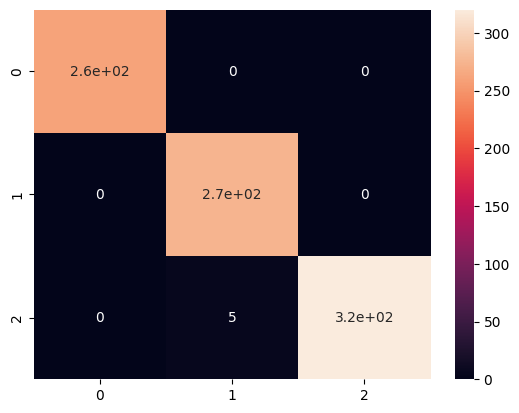

In [39]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [40]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       261
           1       0.98      1.00      0.99       274
           2       1.00      0.98      0.99       325

    accuracy                           0.99       860
   macro avg       0.99      0.99      0.99       860
weighted avg       0.99      0.99      0.99       860



In [41]:
from sklearn.model_selection import cross_val_score
cv = cross_val_score(estimator=final_model, X=x_train, y=y_train, cv=10)
print(cv.std())
print(cv.mean())

0.00721492653836679
0.9918604651162791


In [42]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'The accuracy of the model is {round(accuracy, 2)*100}')

The accuracy of the model is 99.0


In [43]:
best_model = trained_models['Random Forest']
jb.dump(best_model, 'WQD.joblib')

['WQD.joblib']

In [44]:
jb.dump(sc, 'WQD_scaler.joblib')

['WQD_scaler.joblib']